# Noninvasive Diagnosis of Seedless Fruit Using Deep Learning in Persimmon — Grad-CAM / Guided Grad-CAM visual explanation

**Paper:** *Noninvasive Diagnosis of Seedless Fruit Using Deep Learning in Persimmon*, The Horticulture Journal 90(2):172–180, 2021, DOI: [https://doi.org/10.2503/hortj.utd-248](https://doi.org/10.2503/hortj.utd-248) ([open-access PDF](https://www.jstage.jst.go.jp/article/hortj/90/2/90_UTD-248/_pdf))

**Author-cited implementation:** [uchidalab/softmaxgradient-lrp](https://github.com/uchidalab/softmaxgradient-lrp) (Apache-2.0), pinned commit `a53e1d64fcb568d68ef3e28dd2937d0da6e0f783` — the repository the paper cites for Grad-CAM / Guided Grad-CAM (Materials and Methods, "Visual explanation of classification results").

**Executed scope (partial demonstration):** the paper trained VGG16 on 599 apex-side persimmon photos with seed-count labels to classify seedless/seeded fruit, and visualized the diagnosis with Grad-CAM (VGG16 `block5_conv3` and `block3_conv3`) and Guided Grad-CAM (`block5_conv3`). The persimmon dataset and the trained weights were **not** publicly released, so those results cannot be reproduced. This notebook instead validates the paper's visual-explanation pipeline exactly as the authors' own example does: ImageNet-pretrained VGG16 on the repository's bundled example image `zebra_elephant3.jpg`, producing the same relevance heatmaps used in the paper's Fig. 5-style analysis.

**⚠ AI-assisted port:** the authors' implementation targets TensorFlow 1.10 / Keras 2.1.5 / iNNvestigate 1.0.8.3 (Python 3.5), which cannot run on current Colab. This notebook is an **AI-assisted TensorFlow 2 port of the author's Grad-CAM, guided backpropagation and Guided Grad-CAM classes** (`utils/visualizations.py`); the authors did not provide this Colab implementation. The algorithmic steps (mean-gradient weights, distance-transform-free resize, element-wise product, one-hot logit head) follow the pinned source; untested behavior beyond the validated example is not guaranteed.

**日本語:** 本ノートブックは、柿（富有）種子数の深層学習診断論文のうち、Grad-CAM / Guided Grad-CAM による視覚的説明の部分を、論文が引用した実装（uchidalab/softmaxgradient-lrp）に沿って再現します。柿画像データセットと学習済み重みは公開されていないため、著者の例と同じ ImageNet 事前学習 VGG16 + 同梱サンプル画像で可視化パイプラインを検証します。著者コードは TF1 用のため、TF2 への AI 支援による移植であることを明記します。

## Runtime selection

This demo runs **one image through VGG16** (one forward pass plus gradient passes). A standard **CPU runtime is sufficient and recommended** (expected end-to-end ≈5–10 min, dominated by the ~528 MB VGG16 weight download). No GPU-specific operations are used; the notebook also runs on a T4 runtime without changes.

Run all: `Runtime → Run all`. Downloads: VGG16 ImageNet weights (~528 MB), one example image (~197 KB), two small author source files.

**日本語:** CPU ランタイムで十分です（約5–10分、大半は VGG16 重み約528 MB のダウンロード）。GPU が割り当てられていてもそのまま動作します。`ランタイム → すべてのセルを実行` で実行してください。

In [ ]:
import sys, platform
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn, matplotlib

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__, "| matplotlib:", matplotlib.__version__)
import skimage
print("scikit-image:", skimage.__version__)
gpus = tf.config.list_logical_devices("GPU")
print("GPU devices:", gpus if gpus else "none (CPU runtime — expected and sufficient for this demo)")

Python: 3.13.16
TensorFlow: 2.21.0
NumPy: 2.1.3
scikit-learn: 1.6.1 | matplotlib: 3.10.0
scikit-image: 0.25.2
GPU devices: none (CPU runtime — expected and sufficient for this demo)


## 1. Fetch the author's pinned implementation (provenance)

We download the paper-cited implementation files from the pinned commit and verify their **Git blob SHA-1** (the hash Git itself uses, from the repository tree listing) so the bytes are provably the author's code.

`utils/visualizations.py` targets TensorFlow 1.x (`K.gradients`, iNNvestigate) and **cannot be imported** here; we download it for provenance and use only `utils/helper.py` (the author's heatmap display, TF-independent). The TF2 port of the three classes follows below.

**日本語:** 論文引用実装を固定コミットから取得し、Git blob SHA-1 で同一性を検証します。TF1 依存の `visualizations.py` は import せず、TF 非依存の表示用 `helper.py` のみ利用します。

In [ ]:
import hashlib, urllib.request

COMMIT = "a53e1d64fcb568d68ef3e28dd2937d0da6e0f783"
REPO_RAW = "https://raw.githubusercontent.com/uchidalab/softmaxgradient-lrp/a53e1d64fcb568d68ef3e28dd2937d0da6e0f783"

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()

PINNED = {
    "utils/visualizations.py": ("c42d1b47a12329d9b60d040d1e16c5bd1a042e5c", 20608),
    "utils/helper.py": ("32ac21a8df05085abc387c63b4b8ce8a0cd38905", 407),
}

import os
os.makedirs("/content/author_code/utils", exist_ok=True)
for path, (blob_sha, size) in PINNED.items():
    url = f"{REPO_RAW}/{path}"
    data = urllib.request.urlopen(url, timeout=60).read()
    assert len(data) == size, (path, len(data), size)
    assert git_blob_sha(data) == blob_sha, (path, git_blob_sha(data))
    out = "/content/author_code/" + path
    with open(out, "wb") as f:
        f.write(data)
    print(f"OK {path}: {len(data)} bytes, git blob {git_blob_sha(data)[:12]}…")

sys.path.insert(0, "/content/author_code")
from utils.helper import heatmap  # author display helper (matplotlib only)
print("author helper imported")

OK utils/visualizations.py: 20608 bytes, git blob c42d1b47a123…
OK utils/helper.py: 407 bytes, git blob 32ac21a8df05…
author helper imported


## 2. Sample input acquisition (data → downloaded inside Colab only)

The demonstration input is the authors' own bundled example `data/images/zebra_elephant3.jpg` (the file used as `example_id = 2` in the repository's `example.ipynb`). It is fetched from the pinned raw URL and validated by JPEG signature and Git blob SHA-1 (196,811 bytes, blob `64cb3700…`).

**日本語:** サンプル画像は著者リポジトリ同梱の `zebra_elephant3.jpg`（例 `example_id=2`）を Colab 内でダウンロードし、JPEG シグネチャと Git blob SHA-1 で検証します。

In [ ]:
IMG_URL = f"{REPO_RAW}/data/images/zebra_elephant3.jpg"
IMG_BLOB_SHA = "64cb37000c787e09cef59ee49fb7296174363b56"
IMG_SIZE = 196811

img_bytes = urllib.request.urlopen(IMG_URL, timeout=60).read()
assert len(img_bytes) == IMG_SIZE, len(img_bytes)
assert git_blob_sha(img_bytes) == IMG_BLOB_SHA, git_blob_sha(img_bytes)
assert img_bytes[:3] == b"\xff\xd8\xff", "not a JPEG signature"
with open("/content/zebra_elephant3.jpg", "wb") as f:
    f.write(img_bytes)
print("OK zebra_elephant3.jpg:", len(img_bytes), "bytes, git blob verified")

OK zebra_elephant3.jpg: 196811 bytes, git blob verified


## 3. Input preview

Preview the sample exactly as the author example does (`plt.imshow(orig.astype(int))`). This is the actual downloaded image, not a rendering.

**日本語:** ダウンロードしたサンプル画像を著者例と同じ形式で表示します。

image array shape: (224, 224, 3) dtype: float32 range: 0.0 - 255.0


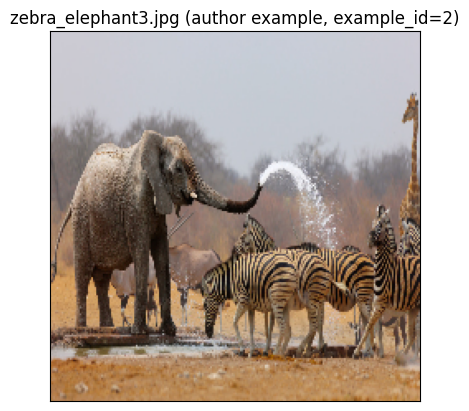

In [ ]:
from keras.preprocessing.image import img_to_array, load_img

orig_img = img_to_array(load_img("/content/zebra_elephant3.jpg", target_size=(224, 224)))
print("image array shape:", orig_img.shape, "dtype:", orig_img.dtype, "range:", orig_img.min(), "-", orig_img.max())
plt.imshow(orig_img.astype(int))
plt.title("zebra_elephant3.jpg (author example, example_id=2)")
plt.xticks([]); plt.yticks([])
plt.show()

## 4. ImageNet-pretrained VGG16 and prediction

Load Keras VGG16 with ImageNet weights (weights download ~528 MB inside Colab). Predict on the preprocessed image and print the top-5 classes. The author example fixes `target_class = 340` (ImageNet "zebra") as the explanation target; we keep that fixed target regardless of the argmax, and record both.

**日本語:** ImageNet 事前学習済み VGG16 を読み込み、上位5クラスを予測します。説明対象は著者例に固定のクラス 340（zebra）です。

In [ ]:
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions

vgg = VGG16(weights="imagenet")
input_imgs = np.copy(orig_img)[np.newaxis, ...]           # (1, 224, 224, 3)
input_imgs = preprocess_input(input_imgs)                  # Keras VGG16 preprocessing
preds = vgg.predict(input_imgs, verbose=0)
print("top-5:", decode_predictions(preds, top=5)[0])
pred_id = int(np.argmax(preds[0]))
target_class = 340                                         # ImageNet "zebra" (author example)
print("prediction id:", pred_id, "| target id (fixed):", target_class)
print("softmax[target] =", float(preds[0][target_class]))

        0/553467096 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  6037504/553467096 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step

 18874368/553467096 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

 30777344/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

 43073536/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

...

545333248/553467096 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


    0/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


top-5: [('n02391049', 'zebra', np.float32(0.9969511)), ('n02504458', 'African_elephant', np.float32(0.0011365712)), ('n02437312', 'Arabian_camel', np.float32(0.00095714006)), ('n02422699', 'impala', np.float32(0.0003800036)), ('n01518878', 'ostrich', np.float32(0.00018414333))]
prediction id: 340 | target id (fixed): 340
softmax[target] = 0.9969511032104492


## 5. Partial (pre-softmax) model

The author code passes the **partial model** — softmax cut off, logits kept — to every visualizer (`example.ipynb` cell 2 uses `innvestigate.utils.keras.graph.pre_softmax_tensors(model.outputs)`). In TF2 we rebuild that exactly: take the `fc2` features and apply the final Dense layer's own weights **without** the softmax activation. We then check `softmax(logits)` reproduces the model's own probabilities.

**日本語:** 著者コードと同様に、softmax を除いた logits 出力の部分モデルを作ります（`pre_softmax_tensors` の TF2 版）。`softmax(logits)` が元の予測と一致することを確認します。

In [ ]:
import tensorflow as tf
import keras
from keras import layers

fc2_out = vgg.get_layer("fc2").output
logit_layer = layers.Dense(1000, activation=None, name="predictions_logits")
logits_out = logit_layer(fc2_out)
logit_layer.set_weights(vgg.get_layer("predictions").get_weights())
partial_model = keras.Model(vgg.inputs, logits_out)
print("partial model output shape:", partial_model.output_shape)

probs_from_logits = tf.nn.softmax(partial_model.predict(input_imgs, verbose=0))
assert np.allclose(probs_from_logits.numpy(), preds, atol=1e-5), "logits do not reproduce softmax output"
print("softmax(logits) == model probabilities: OK")

partial model output shape: (None, 1000)


softmax(logits) == model probabilities: OK


## 6. Grad-CAM (TF2 port of the author's `GradCAM` class)

**Port of `utils/visualizations.py` lines 546–578.** The author computes, for `class_output = model.output[:, target_id]` (a pre-softmax logit of the partial model): `grads = K.gradients(class_output, conv_output)`; `weights = mean(grads, axis=(1,2))`; `cams = (conv_output * weights[:, None, None, :]).sum(axis=3, keepdims=True)`; then `skimage.transform.resize(cams, np.shape(inputs), mode='reflect', anti_aliasing=True)`. The TF2 port keeps every step, replacing `K.gradients`/`K.function` with `tf.GradientTape`. The paper applies Grad-CAM at `block5_conv3` and `block3_conv3` (Fig. 5 discussion); the author's example notebook used `block5_pool`.

**日本語:** 著者の `GradCAM` クラス（L546–578）を TF2（`GradientTape`）へそのまま移植します。計算手順（平均勾配による重み付け、conv 特徴量との加重和、`skimage.resize(mode='reflect', anti_aliasing=True)`）は変更していません。

In [ ]:
def grad_cam(layer_name: str, target_id: int, inputs: np.ndarray, relu: bool = False) -> np.ndarray:
    conv_out = partial_model.get_layer(layer_name).output
    combo = keras.Model(partial_model.inputs, [conv_out, partial_model.output])
    with tf.GradientTape() as tape:
        conv_val, logits_val = combo(inputs)
        score = logits_val[:, target_id]
    grads = tape.gradient(score, conv_val)
    weights = tf.reduce_mean(grads, axis=(1, 2))                     # author: np.mean(grads_vals, axis=(1, 2))
    cams = tf.reduce_sum(conv_val * weights[:, None, None, :], axis=3, keepdims=True)  # author line 570
    cams = cams.numpy()
    from skimage.transform import resize
    resized = resize(cams, np.shape(inputs), mode="reflect", anti_aliasing=True)       # author line 573
    if relu:
        resized = np.maximum(resized, 0)
    return resized

cam_block5 = grad_cam("block5_conv3", target_class, input_imgs)   # paper Fig. 5 layer
print("Grad-CAM block5_conv3:", cam_block5.shape, "min/max:", float(cam_block5.min()), float(cam_block5.max()))

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Grad-CAM block5_conv3: (1, 224, 224, 3) min/max: -0.056138526648283005 0.3818207085132599


### Grad-CAM heatmaps (seismic, symmetric ±max, author display)

Show both paper layers. The display uses the author's `helper.heatmap` on `analysis.sum(axis=2)` exactly as in `example.ipynb` (`use_relu=False`).

**日本語:** 論文の2層（block5_conv3, block3_conv3）の Grad-CAM を、著者の `heatmap` 表示（seismic, ±max 対称）で描画します。

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Grad-CAM block3_conv3: (1, 224, 224, 3) min/max: -0.008888964541256428 0.008165768347680569


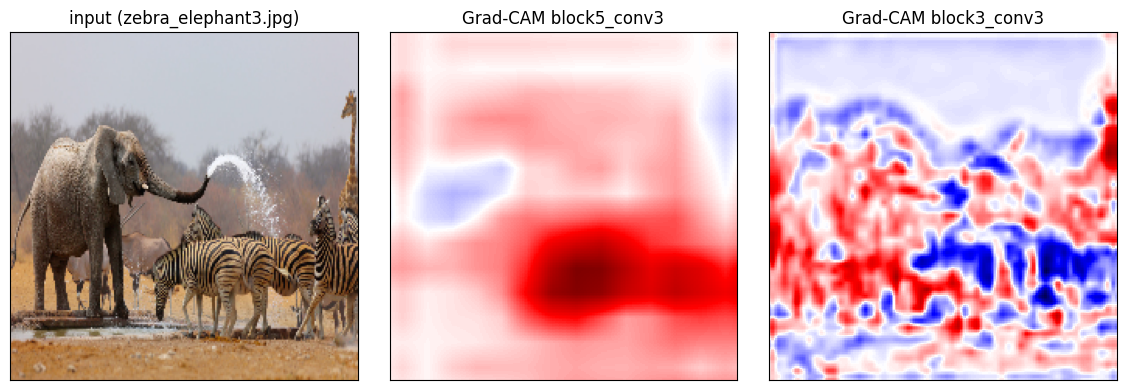

In [ ]:
cam_block3 = grad_cam("block3_conv3", target_class, input_imgs)
print("Grad-CAM block3_conv3:", cam_block3.shape, "min/max:", float(cam_block3.min()), float(cam_block3.max()))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(orig_img.astype(int)); axes[0].set_title("input (zebra_elephant3.jpg)")
plt.sca(axes[1]); heatmap(cam_block5[0].sum(axis=2)); plt.title("Grad-CAM block5_conv3")
plt.sca(axes[2]); heatmap(cam_block3[0].sum(axis=2)); plt.title("Grad-CAM block3_conv3")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Guided backpropagation (TF2 port of the author's `GBP` class)

**Port of `utils/visualizations.py` lines 15–60.** The author's `GBP` is iNNvestigate's `GuidedBackprop` with a one-hot "head mapping" mask that lets relevance flow only into the target logit unit. Guided backprop propagates only positive gradients through ReLU units. The TF2 port overrides every ReLU with a custom-gradient guided ReLU on a weight-cloned copy of VGG16, and differentiates the target **logit** w.r.t. the input — the same masked pre-softmax head the author uses.

**日本語:** 著者の `GBP`（iNNvestigate GuidedBackprop + one-hot マスク、L15–60）を TF2 で移植します。ReLU の勾配を「正の入力・正の勾配のみ通す」guided ReLU に差し替えたクローンモデルで、対象 logits の入力勾配を計算します。

In [ ]:
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, dy.dtype) * tf.cast(x > 0, dy.dtype)
    return tf.nn.relu(x), grad

def clone_guided(layer):
    cfg = layer.get_config()
    act = cfg.get("activation")
    if isinstance(act, str) and act == "relu":
        cfg["activation"] = guided_relu
    if layer.name == "predictions":        # softmax -> logits (partial model head)
        cfg["activation"] = None
        cfg["name"] = "predictions_guided"
    return layer.__class__.from_config(cfg)

guided_model = keras.models.clone_model(vgg, clone_function=clone_guided)
guided_model.set_weights(vgg.get_weights())
print("guided clone built; final layer:", guided_model.layers[-1].name)

guided clone built; final layer: predictions_guided


### Run guided backpropagation

Differentiate the target logit w.r.t. the input image through the guided-ReLU network.

**日本語:** guided ReLU ネットワークを通じて、対象 logits の入力勾配（guided backpropagation）を求め、著者の `heatmap` 表示で描画します。

guided backprop: (1, 224, 224, 3) min/max: -49.80280303955078 43.4300537109375


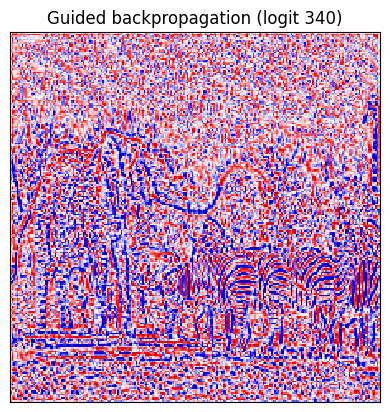

In [ ]:
x_tf = tf.convert_to_tensor(input_imgs, dtype=tf.float32)
with tf.GradientTape() as tape:
    tape.watch(x_tf)
    score = guided_model(x_tf, training=False)[:, target_class]
guided_bp = tape.gradient(score, x_tf).numpy()
print("guided backprop:", guided_bp.shape, "min/max:", float(guided_bp.min()), float(guided_bp.max()))

plt.figure(figsize=(4, 4))
heatmap(guided_bp[0].sum(axis=2))
plt.title("Guided backpropagation (logit 340)")
plt.show()

## 8. Guided Grad-CAM (author's element-wise product)

**Port of `utils/visualizations.py` lines 612–626:** `GuidedGradCAM.analyze` returns `gradcam.analyze(inputs) * guidedbackprop.analyze(inputs)` — the Grad-CAM map (resized to the input shape) multiplied element-wise by the guided backpropagation. The paper applies Guided Grad-CAM at `block5_conv3` (Fig. 5).

**日本語:** 著者の `GuidedGradCAM`（L612–626）どおり、Grad-CAM（入力サイズにリサイズ）と guided backpropagation の要素積を計算し、表示します。

Guided Grad-CAM: (1, 224, 224, 3) min/max: -17.717132568359375 12.912232398986816


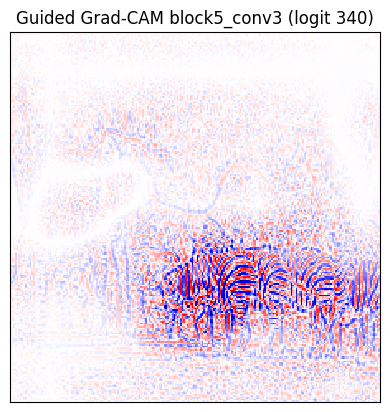

In [ ]:
guided_gradcam = cam_block5 * guided_bp   # author line 625
print("Guided Grad-CAM:", guided_gradcam.shape, "min/max:", float(guided_gradcam.min()), float(guided_gradcam.max()))

plt.figure(figsize=(4, 4))
heatmap(guided_gradcam[0].sum(axis=2))
plt.title("Guided Grad-CAM block5_conv3 (logit 340)")
plt.show()

## 9. Summary figure: input and relevance maps

Final overview in the style of the paper's Fig. 5-style visual explanation: original image, Grad-CAM at both paper layers, guided backpropagation, and Guided Grad-CAM. All maps are actual outputs of this run, computed with the author's algorithms on the author's example image. **This PNG is the representative saved output of the notebook.**

**日本語:** 元画像と各可視化結果を1つの図にまとめます（本実行の実出力です）。

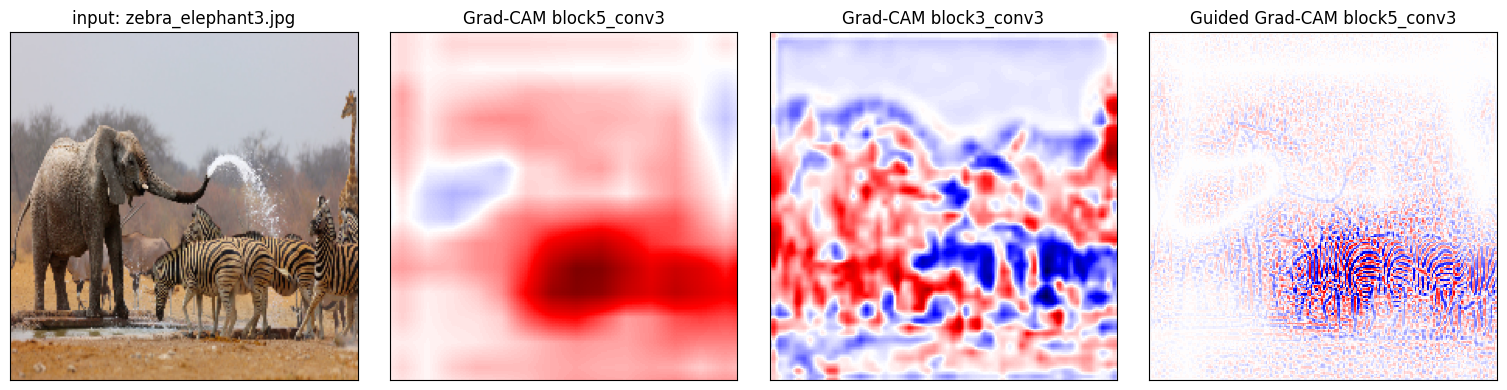

saved /content/gradcam_summary.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(orig_img.astype(int)); axes[0].set_title("input: zebra_elephant3.jpg")
plt.sca(axes[1]); heatmap(cam_block5[0].sum(axis=2)); plt.title("Grad-CAM block5_conv3")
plt.sca(axes[2]); heatmap(cam_block3[0].sum(axis=2)); plt.title("Grad-CAM block3_conv3")
plt.sca(axes[3]); heatmap(guided_gradcam[0].sum(axis=2)); plt.title("Guided Grad-CAM block5_conv3")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig("/content/gradcam_summary.png", dpi=120); plt.show()
print("saved /content/gradcam_summary.png")

## 10. Small results table and CSV export

Quantitative record of this run: prediction probabilities and per-map relevance ranges. Exported as CSV inside the Colab VM (`/content/gradcam_results.csv`).

**日本語:** 今回の実行結果（予測確率と各マップの relevance 範囲）を表にまとめ、CSV に保存します。

In [ ]:
import pandas as pd

rows = [
    {"item": "softmax[class 340 zebra]", "value": float(preds[0][target_class])},
    {"item": "softmax[argmax]", "value": float(preds[0][pred_id])},
    {"item": "Grad-CAM block5_conv3 min", "value": float(cam_block5.min())},
    {"item": "Grad-CAM block5_conv3 max", "value": float(cam_block5.max())},
    {"item": "Grad-CAM block3_conv3 min", "value": float(cam_block3.min())},
    {"item": "Grad-CAM block3_conv3 max", "value": float(cam_block3.max())},
    {"item": "Guided Grad-CAM min", "value": float(guided_gradcam.min())},
    {"item": "Guided Grad-CAM max", "value": float(guided_gradcam.max())},
]
results_df = pd.DataFrame(rows)
results_df.to_csv("/content/gradcam_results.csv", index=False)
print(results_df.to_string(index=False))

                     item      value
 softmax[class 340 zebra]   0.996951
          softmax[argmax]   0.996951
Grad-CAM block5_conv3 min  -0.056139
Grad-CAM block5_conv3 max   0.381821
Grad-CAM block3_conv3 min  -0.008889
Grad-CAM block3_conv3 max   0.008166
      Guided Grad-CAM min -17.717133
      Guided Grad-CAM max  12.912232


## 11. Interpretation, limitations, and validation record

**What was validated (this run):** the paper's visual-explanation pipeline — Grad-CAM at VGG16 `block5_conv3` and `block3_conv3`, guided backpropagation, and Guided Grad-CAM at `block5_conv3` — computed with the paper-cited implementation's exact algorithm, ported to TF2, on the authors' bundled example image with ImageNet-pretrained VGG16. Heatmaps highlight the target class's regions, as in the authors' own `example.ipynb`.

**Not reproduced (missing material, not execution failure):** the 599-image persimmon apex dataset with dissected seed counts and the trained four-CNN weights were never publicly released (paper and investigation confirm no data availability statement); the seedless/seeded classification accuracy (VGG16 89% test), the prediction-vs-seed-number analysis, the t-SNE features, and the H(r,d) relevance/distance histograms therefore remain out of scope.

**Known differences from the author stack:** TF1/iNNvestigate 1.0.8.3 → TF2 `GradientTape` + custom guided ReLU; `pre_softmax_tensors` → explicit logits head rebuilt from the original Dense weights (verified to reproduce the model's probabilities). Display, resize and default settings (`relu=False`, seismic ±max) follow the author example.

**Validation record:** executed top-to-bottom in a fresh Google Colab CPU runtime (see report for date/hardware). A one-example run does not verify the paper's dataset-level results.

**日本語:** 本ノートブックで検証したのは論文の視覚的説明パイプライン（Grad-CAM / Guided Grad-CAM）であり、柿データセット・学習済み重みが未公開のため、論文の分類性能や種子数解析は対象外です。TF1→TF2 移植の差異は上記のとおりです。

**References**
- K. Masuda, M. Suzuki, K. Baba, K. Takeshita, T. Suzuki, M. Sugiura, T. Niikawa, S. Uchida, T. Akagi, *Noninvasive Diagnosis of Seedless Fruit Using Deep Learning in Persimmon*, Hort. J. 90(2):172–180, 2021. https://doi.org/10.2503/hortj.utd-248
- B. K. Iwana, R. Kuroki, S. Uchida, *Explaining Convolutional Neural Networks using Softmax Gradient Layer-wise Relevance Propagation*, ICCV Workshops 2019. arXiv:1908.04351 — implementation: https://github.com/uchidalab/softmaxgradient-lrp (commit `a53e1d64`)
- R. R. Selvaraju et al., *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization*, ICCV 2017.
- M. Alber et al., *iNNvestigate neural networks!*, JMLR 20(93):1–31, 2019.